# Exploratory Data Analysis & Treatment Strategies



## DEMAB : LTN and NTN-F

In [1]:
import pandas as pd
path_demab_refined = r"C:\Users\Dell\OneDrive\Documentos\GitHub\ML-ETTJ26\data\03_refined\bcb\demab\demab_government_bonds_secondary_market_refined.parquet"
demab_refined = pd.read_parquet(path_demab_refined)
demab_refined.info()

<class 'pandas.DataFrame'>
RangeIndex: 197738 entries, 0 to 197737
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   date              197738 non-null  datetime64[us]
 1   isin              197738 non-null  str           
 2   sigla             197738 non-null  str           
 3   pu_lastro         197738 non-null  float64       
 4   valor_par         197522 non-null  float64       
 5   issue_date        197738 non-null  datetime64[us]
 6   maturity          197738 non-null  datetime64[us]
 7   days_to_maturity  197738 non-null  int64         
 8   bd_to_maturity    197738 non-null  int64         
 9   pu_min            187169 non-null  float64       
 10  pu_med            187169 non-null  float64       
 11  pu_max            187169 non-null  float64       
 12  taxa_min          102480 non-null  float64       
 13  taxa_med          102480 non-null  float64       
 14  taxa_max       

In [9]:
df_ltn = demab_refined[demab_refined["sigla"]=="LTN"]
df_ntnf = demab_refined[demab_refined["sigla"]=="NTN-F"]

value_columns = ["date", "isin", "pu_med", "taxa_med", "pu_min", "pu_max", "taxa_min", "taxa_max"]
df_ltn_pu_null = df_ltn[df_ltn["pu_med"].isna()][value_columns]
df_ntnf_pu_null = df_ntnf[df_ntnf["pu_med"].isna()][value_columns]
print(df_ltn_pu_null.info())
print(df_ntnf_pu_null.info())

<class 'pandas.DataFrame'>
Index: 2699 entries, 71 to 196499
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   date      2699 non-null   datetime64[us]
 1   isin      2699 non-null   str           
 2   pu_med    0 non-null      float64       
 3   taxa_med  0 non-null      float64       
 4   pu_min    0 non-null      float64       
 5   pu_max    0 non-null      float64       
 6   taxa_min  0 non-null      float64       
 7   taxa_max  0 non-null      float64       
dtypes: datetime64[us](1), float64(6), str(1)
memory usage: 221.7 KB
None
<class 'pandas.DataFrame'>
Index: 1095 entries, 24 to 162169
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   date      1095 non-null   datetime64[us]
 1   isin      1095 non-null   str           
 2   pu_med    0 non-null      float64       
 3   taxa_med  0 non-null      float64       
 4  

In [20]:
print(f"Quantidade de ISINs com PU_MED nulo - LTN: {len(df_ltn_pu_null['isin'].unique())}")
print(f"Quantidade de ISINs com PU_MED nulo - NTN-F: {len(df_ntnf_pu_null['isin'].unique())}")

Quantidade de ISINs com PU_MED nulo - LTN: 82
Quantidade de ISINs com PU_MED nulo - NTN-F: 17


In [15]:
df_ntnf[df_ntnf["pu_med"].isna()].info()

<class 'pandas.DataFrame'>
Index: 1095 entries, 24 to 162169
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   date              1095 non-null   datetime64[us]
 1   isin              1095 non-null   str           
 2   sigla             1095 non-null   str           
 3   pu_lastro         1095 non-null   float64       
 4   valor_par         1095 non-null   float64       
 5   issue_date        1095 non-null   datetime64[us]
 6   maturity          1095 non-null   datetime64[us]
 7   days_to_maturity  1095 non-null   int64         
 8   bd_to_maturity    1095 non-null   int64         
 9   pu_min            0 non-null      float64       
 10  pu_med            0 non-null      float64       
 11  pu_max            0 non-null      float64       
 12  taxa_min          0 non-null      float64       
 13  taxa_med          0 non-null      float64       
 14  taxa_max          0 non-null      flo

In [4]:
df_ltn.head()

,date,isin,sigla,pu_lastro,valor_par,issue_date,maturity,days_to_maturity,bd_to_maturity,pu_min,pu_med,pu_max,taxa_min,taxa_med,taxa_max,source,raw_hash
3,2007-01-02,BRSTNCLTN616,LTN,970.434579,1000.0,2005-09-28,2007-04-01,89,61,970.610716,970.717343,970.746275,12.83,12.84,12.89,BCB_DEMAB,c357e07c5d7074675e559fbbd1dce2fb9fc05c1c869939...
5,2007-01-02,BRSTNCLTN5Z0,LTN,942.652166,1000.0,2005-06-01,2007-07-01,180,123,943.072252,943.260185,944.351897,12.34,12.60,12.65,BCB_DEMAB,c357e07c5d7074675e559fbbd1dce2fb9fc05c1c869939...
7,2007-01-02,BRSTNCLTN632,LTN,914.961886,1000.0,2006-02-13,2007-10-01,272,188,915.940780,916.025352,916.305420,12.43,12.48,12.49,BCB_DEMAB,c357e07c5d7074675e559fbbd1dce2fb9fc05c1c869939...
9,2007-01-02,BRSTNCLTN608,LTN,889.006040,1000.0,2005-07-22,2008-01-01,364,249,882.869221,890.316632,892.080224,12.20,12.42,13.38,BCB_DEMAB,c357e07c5d7074675e559fbbd1dce2fb9fc05c1c869939...
11,2007-01-02,BRSTNCLTN657,LTN,863.854887,1000.0,2006-08-04,2008-04-01,455,311,865.471089,865.471089,865.471089,12.42,12.42,12.42,BCB_DEMAB,c357e07c5d7074675e559fbbd1dce2fb9fc05c1c869939...


### Engine

In [5]:
df_failures = pd.read_parquet(r"C:\Users\Dell\OneDrive\Documentos\GitHub\ML-ETTJ26\data\04_feature\curve_factory\public_bonds\mart_public_bonds_curve_calculation_failures_batch.parquet")
df_failures

,ref_date,instrument_type,isin,issue_date,maturity_date,bd_to_maturity,pu_med,taxa_med,quote_quality,quote_source,primary_quote_type,calculation_status,calculation_error_type,calculation_error_message
0,2010-12-20,NTN-F,BRSTNCNTF0L9,2007-07-06,2011-01-01,8,48.612300,NaN,OBSERVED_PU,PU_MED,PRICE,FAILED,RuntimeError,All yield solvers failed. SingleCashflowYieldS...
1,2010-12-20,NTN-F,BRSTNCNTF0P0,2010-12-15,2011-07-01,133,46.087200,NaN,OBSERVED_PU,PU_MED,PRICE,FAILED,RuntimeError,All yield solvers failed. SingleCashflowYieldS...
2,2012-12-24,NTN-F,BRSTNCNTF0T2,2011-12-19,2013-01-01,5,48.742107,NaN,OBSERVED_PU,PU_MED,PRICE,FAILED,RuntimeError,All yield solvers failed. SingleCashflowYieldS...
3,2018-07-06,LTN,,2018-07-06,2020-10-01,564,9576.294587,0.0241,OBSERVED_PU,PU_MED,PRICE,FAILED,InvalidPrice,Market price 9576.294587 is above Notional (50...


In [14]:
df_candidates = pd.read_parquet(r"C:\Users\Dell\OneDrive\Documentos\GitHub\ML-ETTJ26\data\04_feature\curve_factory\public_bonds\mart_public_bonds_curve_inputs_batch.parquet")
df_candidates.info()

<class 'pandas.DataFrame'>
RangeIndex: 69419 entries, 0 to 69418
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ref_date                69419 non-null  object 
 1   instrument_type         69419 non-null  str    
 2   isin                    69419 non-null  str    
 3   issue_date              69419 non-null  object 
 4   maturity_date           69419 non-null  object 
 5   bd_to_maturity          69419 non-null  int64  
 6   market_pu               69419 non-null  float64
 7   market_ytm              69419 non-null  float64
 8   macaulay_duration       69419 non-null  float64
 9   modified_duration       69419 non-null  float64
 10  numero_observacoes_dia  69419 non-null  int64  
 11  flag_volume             69419 non-null  str    
 12  flag_cobertura_tenors   69419 non-null  str    
 13  quote_quality           69419 non-null  str    
 14  quote_source            69419 non-null  str    
 

In [15]:
print(df_candidates[df_candidates["instrument_type"]=="NTN-F"]["solver_iterations"].describe())
print(df_candidates["solver_method"].value_counts())

count    25799.000000
mean         4.580216
std          0.537808
min          2.000000
25%          4.000000
50%          5.000000
75%          5.000000
max          6.000000
Name: solver_iterations, dtype: float64
solver_method
ZERO_COUPON     43620
NEWTON_BATCH    25799
Name: count, dtype: int64


In [16]:
from datetime import date

print(len(df_candidates["ref_date"].unique()))
print(df_candidates["ref_date"].unique()[[0, -1]])

df_candidates[df_candidates["ref_date"] == date(2018, 7, 6)] # dia com candidato descartado por PU impossível

4788
[datetime.date(2007, 1, 2) datetime.date(2026, 1, 30)]


,ref_date,instrument_type,isin,issue_date,maturity_date,bd_to_maturity,market_pu,market_ytm,macaulay_duration,modified_duration,numero_observacoes_dia,flag_volume,flag_cobertura_tenors,quote_quality,quote_source,primary_quote_type,market_pu_source,market_ytm_source,solver_method,solver_iterations
38487,2018-07-06,LTN,BRSTNCLTN7E1,2016-07-08,2018-10-01,61,985.169689,0.064765,0.238095,0.223613,17,HIGH,GOOD,OBSERVED_PU,PU_MED,PRICE,PU_MED,IMPLIED_FROM_PU_MED,ZERO_COUPON,0
38488,2018-07-06,LTN,BRSTNCLTN764,2015-01-09,2019-01-01,122,969.012165,0.067181,0.484127,0.453650,17,HIGH,GOOD,OBSERVED_PU,PU_MED,PRICE,PU_MED,IMPLIED_FROM_PU_MED,ZERO_COUPON,0
38489,2018-07-06,LTN,BRSTNCLTN7G6,2017-01-06,2019-04-01,184,950.420318,0.072534,0.726190,0.677079,17,HIGH,GOOD,OBSERVED_PU,PU_MED,PRICE,PU_MED,IMPLIED_FROM_PU_MED,ZERO_COUPON,0
38490,2018-07-06,LTN,BRSTNCLTN798,2015-07-03,2019-07-01,246,931.139366,0.076145,0.972222,0.903431,17,HIGH,GOOD,OBSERVED_PU,PU_MED,PRICE,PU_MED,IMPLIED_FROM_PU_MED,ZERO_COUPON,0
38491,2018-07-06,LTN,BRSTNCLTN7H4,2017-07-07,2019-10-01,312,908.537532,0.080822,1.234127,1.141841,17,HIGH,GOOD,OBSERVED_PU,PU_MED,PRICE,PU_MED,IMPLIED_FROM_PU_MED,ZERO_COUPON,0
38492,2018-07-06,LTN,BRSTNCLTN7B7,2016-01-08,2020-01-01,375,888.173459,0.082953,1.488095,1.374109,17,HIGH,GOOD,OBSERVED_PU,PU_MED,PRICE,PU_MED,IMPLIED_FROM_PU_MED,ZERO_COUPON,0
38493,2018-07-06,LTN,BRSTNCLTN7J0,2018-01-05,2020-04-01,438,869.054359,0.084299,1.734127,1.599307,17,HIGH,GOOD,OBSERVED_PU,PU_MED,PRICE,PU_MED,IMPLIED_FROM_PU_MED,ZERO_COUPON,0
38494,2018-07-06,LTN,BRSTNCLTN7F8,2016-07-08,2020-07-01,499,847.328068,0.087446,1.976190,1.817277,17,HIGH,GOOD,OBSERVED_PU,PU_MED,PRICE,PU_MED,IMPLIED_FROM_PU_MED,ZERO_COUPON,0
38495,2018-07-06,LTN,BRSTNCLTN7I2,2017-07-07,2021-07-01,750,759.466019,0.096990,2.972222,2.709433,17,HIGH,GOOD,OBSERVED_PU,PU_MED,PRICE,PU_MED,IMPLIED_FROM_PU_MED,ZERO_COUPON,0
38496,2018-07-06,LTN,BRSTNCLTN7K8,2018-01-05,2022-01-01,876,714.962331,0.101212,3.480159,3.160300,17,HIGH,GOOD,OBSERVED_PU,PU_MED,PRICE,PU_MED,IMPLIED_FROM_PU_MED,ZERO_COUPON,0


In [17]:
df_candidates["market_pu"].describe()

count    69419.000000
mean       908.686878
std        117.367779
min        374.224161
25%        842.665755
50%        928.098857
75%        981.999342
max       1274.007687
Name: market_pu, dtype: float64

In [18]:
df_candidates["market_ytm"].describe()

count    69419.000000
mean         0.107163
std          0.032199
min          0.017910
25%          0.089179
50%          0.112985
75%          0.127609
max          3.503610
Name: market_ytm, dtype: float64

In [19]:
df_candidates[df_candidates["market_ytm"] > 0.2]

,ref_date,instrument_type,isin,issue_date,maturity_date,bd_to_maturity,market_pu,market_ytm,macaulay_duration,modified_duration,numero_observacoes_dia,flag_volume,flag_cobertura_tenors,quote_quality,quote_source,primary_quote_type,market_pu_source,market_ytm_source,solver_method,solver_iterations
2063,2007-11-27,LTN,BRSTNCLTN608,2005-07-22,2008-01-01,23,931.683256,1.102243,0.095238,0.045303,10,MEDIUM,GOOD,OBSERVED_PU,PU_MED,PRICE,PU_MED,IMPLIED_FROM_PU_MED,ZERO_COUPON,0
2073,2007-11-28,LTN,BRSTNCLTN608,2005-07-22,2008-01-01,22,969.136164,0.409858,0.091270,0.064737,9,MEDIUM,GOOD,OBSERVED_PU,PU_MED,PRICE,PU_MED,IMPLIED_FROM_PU_MED,ZERO_COUPON,0
3886,2008-09-15,NTN-F,BRSTNCNTF055,2005-02-02,2010-01-01,325,895.135384,0.223108,1.223130,1.000018,8,MEDIUM,GOOD,OBSERVED_PU,PU_MED,PRICE,PU_MED,IMPLIED_FROM_PU_MED,NEWTON_BATCH,5
4164,2008-10-27,NTN-F,BRSTNCNTF0I5,2007-07-06,2011-01-01,546,844.008168,0.220000,1.921048,1.574630,9,MEDIUM,GOOD,OBSERVED_PU,PU_MED,PRICE,PU_MED,IMPLIED_FROM_PU_MED,NEWTON_BATCH,5
4217,2008-11-04,LTN,BRSTNCLTN640,2006-05-05,2009-01-01,40,945.927014,0.407302,0.162698,0.115610,8,MEDIUM,GOOD,OBSERVED_PU,PU_MED,PRICE,PU_MED,IMPLIED_FROM_PU_MED,ZERO_COUPON,0
4657,2009-01-12,NTN-F,BRSTNCNTF0H7,2007-02-09,2010-07-01,367,862.406295,0.227661,1.382408,1.126050,10,MEDIUM,GOOD,OBSERVED_PU,PU_MED,PRICE,PU_MED,IMPLIED_FROM_PU_MED,NEWTON_BATCH,5
6950,2009-12-01,NTN-F,BRSTNCNTF055,2005-02-02,2010-01-01,20,1016.848775,0.425439,0.087302,0.061245,11,MEDIUM,GOOD,OBSERVED_PU,PU_MED,PRICE,PU_MED,IMPLIED_FROM_PU_MED,NEWTON_BATCH,5
12689,2011-12-20,NTN-F,BRSTNCNTF121,2011-12-19,2017-01-01,1266,583.757732,0.289682,3.398852,2.635418,14,HIGH,GOOD,OBSERVED_PU,PU_MED,PRICE,PU_MED,IMPLIED_FROM_PU_MED,NEWTON_BATCH,6
12701,2011-12-21,NTN-F,BRSTNCNTF121,2011-12-19,2017-01-01,1265,584.005786,0.289904,3.394263,2.631407,12,MEDIUM,GOOD,OBSERVED_PU,PU_MED,PRICE,PU_MED,IMPLIED_FROM_PU_MED,NEWTON_BATCH,6
21543,2014-05-15,LTN,BRSTNCLTN6T1,2012-04-05,2014-07-01,32,931.318114,0.751269,0.126984,0.072510,17,HIGH,GOOD,OBSERVED_PU,PU_MED,PRICE,PU_MED,IMPLIED_FROM_PU_MED,ZERO_COUPON,0


count    4788.000000
mean       14.498538
std         3.139171
min         2.000000
25%        12.000000
50%        15.000000
75%        17.000000
max        20.000000
Name: count, dtype: float64

Total days with insufficient observations: 100, Percentual: 2.0886%


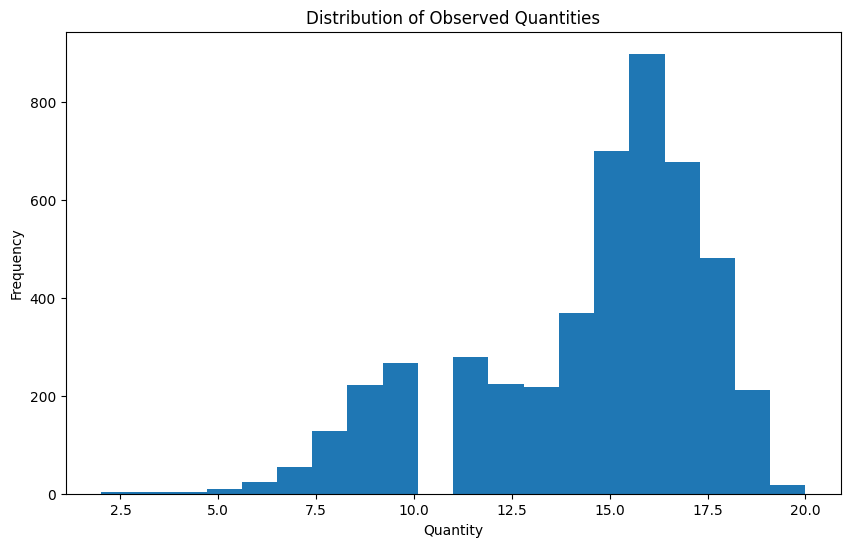

In [68]:
import matplotlib.pyplot as plt

quantity_observed = df_candidates["ref_date"].value_counts()

print(quantity_observed.describe())
print(f"\nTotal days with insufficient observations: {len(quantity_observed[quantity_observed < 8])}, Percentual: {(len(quantity_observed[quantity_observed < 8]) / len(quantity_observed)*100):.4f}%")

plt.figure(figsize=(10, 6))
plt.hist(quantity_observed, bins=20)
plt.xlabel("Quantity")
plt.ylabel("Frequency")
plt.title("Distribution of Observed Quantities")
plt.show()

In [38]:
df_candidates[df_candidates["isin"] == "BRSTNCNTF121"]

,ref_date,instrument_type,isin,issue_date,maturity_date,bd_to_maturity,market_pu,market_ytm,macaulay_duration,modified_duration,quote_quality,quote_source,primary_quote_type,market_pu_source,market_ytm_source,solver_method,solver_iterations,years_to_maturity,dv01,inv_dv01
12689,2011-12-20,NTN-F,BRSTNCNTF121,2011-12-19,2017-01-01,1266,583.757732,0.289682,3.398852,2.635418,OBSERVED_PU,PU_MED,PRICE,PU_MED,IMPLIED_FROM_PU_MED,NEWTON,6,5.023810,0.153845,6.500067
12701,2011-12-21,NTN-F,BRSTNCNTF121,2011-12-19,2017-01-01,1265,584.005786,0.289904,3.394263,2.631407,OBSERVED_PU,PU_MED,PRICE,PU_MED,IMPLIED_FROM_PU_MED,NEWTON,6,5.019841,0.153676,6.507211


In [11]:
df_candidates["modified_duration"].describe()

count    69419.000000
mean         2.096700
std          1.617881
min          0.003450
25%          0.786594
50%          1.688277
75%          3.086321
max          6.853057
Name: modified_duration, dtype: float64

In [12]:
df_candidates["years_to_maturity"] = df_candidates["bd_to_maturity"] / 252
df_candidates["years_to_maturity"].describe()

count    69419.000000
mean         2.832693
std          2.713541
min          0.003968
25%          0.869048
50%          1.900794
75%          3.650794
max         10.932540
Name: years_to_maturity, dtype: float64

In [16]:
df_candidates["dv01"] = df_candidates["modified_duration"] * 0.0001 * df_candidates["market_pu"]
df_candidates["dv01"].describe()

count    69419.000000
mean         0.188762
std          0.157072
min          0.000345
25%          0.073138
50%          0.143892
75%          0.246332
max          0.863247
Name: dv01, dtype: float64

In [18]:
df_candidates["inv_dv01"] = 1 / df_candidates["dv01"]
df_candidates["inv_dv01"].describe()

count    69419.000000
mean        22.096233
std         98.194802
min          1.158417
25%          4.059554
50%          6.949654
75%         13.672777
max       2900.347599
Name: inv_dv01, dtype: float64

In [19]:
df_candidates[df_candidates["inv_dv01"] == df_candidates["inv_dv01"].max()]

,ref_date,instrument_type,isin,issue_date,maturity_date,bd_to_maturity,market_pu,market_ytm,macaulay_duration,modified_duration,quote_quality,quote_source,primary_quote_type,market_pu_source,market_ytm_source,solver_method,solver_iterations,years_to_maturity,dv01,inv_dv01
69026,2025-12-31,LTN,BRSTNCLTN7U7,2020-02-06,2026-01-01,1,999.444535,0.150292,0.003968,0.00345,OBSERVED_PU,PU_MED,PRICE,PU_MED,IMPLIED_FROM_PU_MED,NEWTON,4,0.003968,0.000345,2900.347599


In [20]:
df_candidates[df_candidates["dv01"] == df_candidates["dv01"].max()]

,ref_date,instrument_type,isin,issue_date,maturity_date,bd_to_maturity,market_pu,market_ytm,macaulay_duration,modified_duration,quote_quality,quote_source,primary_quote_type,market_pu_source,market_ytm_source,solver_method,solver_iterations,years_to_maturity,dv01,inv_dv01
44816,2020-02-13,NTN-F,BRSTNCNTF204,2020-01-10,2031-01-01,2725,1264.901335,0.066248,7.27674,6.82462,OBSERVED_PU,PU_MED,PRICE,PU_MED,IMPLIED_FROM_PU_MED,NEWTON,5,10.813492,0.863247,1.158417
